# Chapter 25 — Vectors as Lists of Numbers

So far, we have represented text using token IDs.

A token ID is one integer label, but neural language models need richer numerical objects.

One of the first objects we need is a **vector**: an ordered list of numbers.

In this chapter, every vector operation uses ordinary Python lists and loops.

We will not use NumPy or PyTorch yet.

## Learning goals

By the end of this chapter, you should be able to:

1. Explain what a vector is.
2. Represent a vector as a Python list of numbers.
3. Explain why order matters in a vector.
4. Add two vectors.
5. Multiply a vector by a scalar.
6. Compute a dot product.
7. Print every step of a dot product.
8. Draw simple 2D vectors with `matplotlib.pyplot`.
9. Explain how vectors will appear later in language models.
10. Avoid confusing vectors with unordered bags of numbers.

## What is a vector?

For this course, a vector is an **ordered list of numbers**.

Examples include `[2.0, -1.0, 3.5]`, `[0.2, 0.8]`, and `[5.0, 0.0, -2.0, 7.0]`.

Each number is a **coordinate**.

The number of coordinates is the vector's **dimension**.

In [1]:
vector = [2.0, -1.0, 3.5]

print("Vector:")
print(vector)

print()
print("Dimension:")
print(len(vector))

Vector:
[2.0, -1.0, 3.5]

Dimension:
3


This vector has three coordinates, so it is a 3D vector.

Here, `len(vector)` reports the dimension, not the geometric size of an arrow.

We will use the word **magnitude** for geometric size in a later chapter.

## Coordinates and positions

Each coordinate has a position.

Python indexes start at 0, so the first coordinate is at index 0.

In [2]:
vector = [2.0, -1.0, 3.5]

for index, coordinate in enumerate(vector):
    print(f"index {index}: {coordinate}")

index 0: 2.0
index 1: -1.0
index 2: 3.5


The mathematical first, second, and third coordinates correspond to Python indexes 0, 1, and 2.

The positions are part of the vector's meaning.

## Order matters

A vector is not an unordered bag of numbers.

Changing the coordinate order creates a different vector.

In [3]:
first_vector = [2.0, -1.0, 3.5]
reordered_vector = [3.5, -1.0, 2.0]

print("First vector:", first_vector)
print("Reordered vector:", reordered_vector)
print("Same numbers after sorting:", sorted(first_vector) == sorted(reordered_vector))
print("Same vector:", first_vector == reordered_vector)

First vector: [2.0, -1.0, 3.5]
Reordered vector: [3.5, -1.0, 2.0]
Same numbers after sorting: True
Same vector: False


The lists contain the same numbers, but the first and third coordinates have exchanged roles.

Vector operations pair coordinates by position, so reordering coordinates can change a calculation.

## Validate vectors before using them

Small validation helpers make dimension and data errors easier to understand.

The runtime validator accepts integers and floating-point numbers, but rejects booleans because `True` and `False` should not silently become coordinates.

In [4]:
from collections.abc import Sequence


def assert_vector_of_numbers(vector: Sequence[object]) -> None:
    if len(vector) == 0:
        raise ValueError("A vector must contain at least one number.")

    for position, coordinate in enumerate(vector):
        is_number = isinstance(coordinate, (int, float))

        if not is_number or isinstance(coordinate, bool):
            raise TypeError(
                f"Coordinate at position {position} must be an int or float. "
                f"Received {coordinate!r}."
            )


def assert_same_dimension(
    first_vector: list[float],
    second_vector: list[float],
) -> None:
    assert_vector_of_numbers(first_vector)
    assert_vector_of_numbers(second_vector)

    if len(first_vector) != len(second_vector):
        raise ValueError(
            "Vectors must have the same dimension. "
            f"Received dimensions {len(first_vector)} and {len(second_vector)}."
        )

In [5]:
valid_vector = [2.0, -1.0, 3.5]
same_size_vector = [0.5, 4.0, -2.0]

assert_vector_of_numbers(valid_vector)
assert_same_dimension(valid_vector, same_size_vector)

print("The vectors are valid and have matching dimensions.")

The vectors are valid and have matching dimensions.


## Vector addition

Vector addition adds corresponding coordinates.

For example, `[2.0, -1.0, 3.5] + [0.5, 4.0, -2.0]` equals `[2.5, 3.0, 1.5]`.

Both vectors must have the same dimension so every coordinate has a partner.

In [6]:
def add_vectors(
    first_vector: list[float],
    second_vector: list[float],
) -> list[float]:
    assert_same_dimension(first_vector, second_vector)

    result = []

    for position in range(len(first_vector)):
        coordinate_sum = first_vector[position] + second_vector[position]
        result.append(coordinate_sum)

    return result

In [7]:
first_vector = [2.0, -1.0, 3.5]
second_vector = [0.5, 4.0, -2.0]
sum_vector = add_vectors(first_vector, second_vector)

print("First vector:", first_vector)
print("Second vector:", second_vector)
print("Sum vector:", sum_vector)

assert sum_vector == [2.5, 3.0, 1.5]

First vector: [2.0, -1.0, 3.5]
Second vector: [0.5, 4.0, -2.0]
Sum vector: [2.5, 3.0, 1.5]


### Print vector addition step by step

The next helper exposes the coordinate-by-coordinate work that compact numerical libraries will later perform for us.

In [8]:
def print_vector_addition_steps(
    first_vector: list[float],
    second_vector: list[float],
) -> list[float]:
    assert_same_dimension(first_vector, second_vector)

    result = []

    print("Adding vectors coordinate by coordinate")
    print("-" * 48)

    for position in range(len(first_vector)):
        first_coordinate = first_vector[position]
        second_coordinate = second_vector[position]
        coordinate_sum = first_coordinate + second_coordinate

        print(
            f"position {position}: "
            f"{first_coordinate} + {second_coordinate} = {coordinate_sum}"
        )
        result.append(coordinate_sum)

    print("Result:", result)

    return result

In [9]:
addition_result = print_vector_addition_steps(
    first_vector=[2.0, -1.0, 3.5],
    second_vector=[0.5, 4.0, -2.0],
)

Adding vectors coordinate by coordinate
------------------------------------------------
position 0: 2.0 + 0.5 = 2.5
position 1: -1.0 + 4.0 = 3.0
position 2: 3.5 + -2.0 = 1.5
Result: [2.5, 3.0, 1.5]


## Scalar multiplication

A **scalar** is one number.

Scalar multiplication multiplies every vector coordinate by that same scalar.

For example, `3 × [2.0, -1.0, 3.5]` equals `[6.0, -3.0, 10.5]`.

In [10]:
def multiply_vector_by_scalar(
    scalar: float,
    vector: list[float],
) -> list[float]:
    assert_vector_of_numbers(vector)

    if isinstance(scalar, bool) or not isinstance(scalar, (int, float)):
        raise TypeError("scalar must be an int or float.")

    result = []

    for coordinate in vector:
        result.append(scalar * coordinate)

    return result

In [11]:
vector = [2.0, -1.0, 3.5]
scalar = 3.0
scaled_vector = multiply_vector_by_scalar(scalar, vector)

print("Scalar:", scalar)
print("Vector:", vector)
print("Scaled vector:", scaled_vector)

assert scaled_vector == [6.0, -3.0, 10.5]

Scalar: 3.0
Vector: [2.0, -1.0, 3.5]
Scaled vector: [6.0, -3.0, 10.5]


### Print scalar multiplication step by step

Each output coordinate depends on the scalar and exactly one input coordinate.

In [12]:
def print_scalar_multiplication_steps(
    scalar: float,
    vector: list[float],
) -> list[float]:
    result = multiply_vector_by_scalar(scalar, vector)

    print("Multiplying vector by scalar")
    print("-" * 40)

    for position, coordinate in enumerate(vector):
        print(f"position {position}: {scalar} × {coordinate} = {result[position]}")

    print("Result:", result)

    return result

In [13]:
scalar_result = print_scalar_multiplication_steps(
    scalar=3.0,
    vector=[2.0, -1.0, 3.5],
)

Multiplying vector by scalar
----------------------------------------
position 0: 3.0 × 2.0 = 6.0
position 1: 3.0 × -1.0 = -3.0
position 2: 3.0 × 3.5 = 10.5
Result: [6.0, -3.0, 10.5]


## Dot product

The dot product takes two vectors of the same dimension and returns one number.

It multiplies corresponding coordinates and then adds all the products.

For `[2.0, -1.0, 3.5]` and `[0.5, 4.0, -2.0]`, the calculation is `(2.0 × 0.5) + (-1.0 × 4.0) + (3.5 × -2.0)`.

In [14]:
def dot_product(
    first_vector: list[float],
    second_vector: list[float],
) -> float:
    assert_same_dimension(first_vector, second_vector)

    total = 0.0

    for position in range(len(first_vector)):
        product = first_vector[position] * second_vector[position]
        total = total + product

    return total

In [15]:
first_vector = [2.0, -1.0, 3.5]
second_vector = [0.5, 4.0, -2.0]
dot_product_result = dot_product(first_vector, second_vector)

print("First vector:", first_vector)
print("Second vector:", second_vector)
print("Dot product:", dot_product_result)

assert dot_product_result == -10.0

First vector: [2.0, -1.0, 3.5]
Second vector: [0.5, 4.0, -2.0]
Dot product: -10.0


### Print every dot-product step

The result is one scalar, not another vector.

This vector-to-scalar pattern will appear frequently when models compute scores.

In [16]:
def print_dot_product_steps(
    first_vector: list[float],
    second_vector: list[float],
) -> float:
    assert_same_dimension(first_vector, second_vector)

    products = []
    total = 0.0

    print("Dot product calculation")
    print("-" * 40)

    for position in range(len(first_vector)):
        first_coordinate = first_vector[position]
        second_coordinate = second_vector[position]
        product = first_coordinate * second_coordinate

        products.append(product)
        total = total + product

        print(
            f"position {position}: {first_coordinate} × {second_coordinate} = {product}"
        )

    print("Products:", products)
    print("Sum:", " + ".join(str(product) for product in products), "=", total)

    return total

In [17]:
traced_dot_product = print_dot_product_steps(
    first_vector=[2.0, -1.0, 3.5],
    second_vector=[0.5, 4.0, -2.0],
)

print("Final dot product:", traced_dot_product)

Dot product calculation
----------------------------------------
position 0: 2.0 × 0.5 = 1.0
position 1: -1.0 × 4.0 = -4.0
position 2: 3.5 × -2.0 = -7.0
Products: [1.0, -4.0, -7.0]
Sum: 1.0 + -4.0 + -7.0 = -10.0
Final dot product: -10.0


With simple 2D vectors, `[3.0, 2.0] · [1.0, 4.0]` equals `3.0 × 1.0 + 2.0 × 4.0`, or `11.0`.

In [18]:
two_dimensional_result = print_dot_product_steps(
    first_vector=[3.0, 2.0],
    second_vector=[1.0, 4.0],
)

assert two_dimensional_result == 11.0

Dot product calculation
----------------------------------------
position 0: 3.0 × 1.0 = 3.0
position 1: 2.0 × 4.0 = 8.0
Products: [3.0, 8.0]
Sum: 3.0 + 8.0 = 11.0


## Draw 2D vectors

A 2D vector can be drawn as an arrow from the origin `(0, 0)` to its coordinates.

The diagrams below show a basic vector, vector addition, positive scaling, and negative scaling.

These pictures build intuition, but model vectors will often have too many dimensions to draw directly.

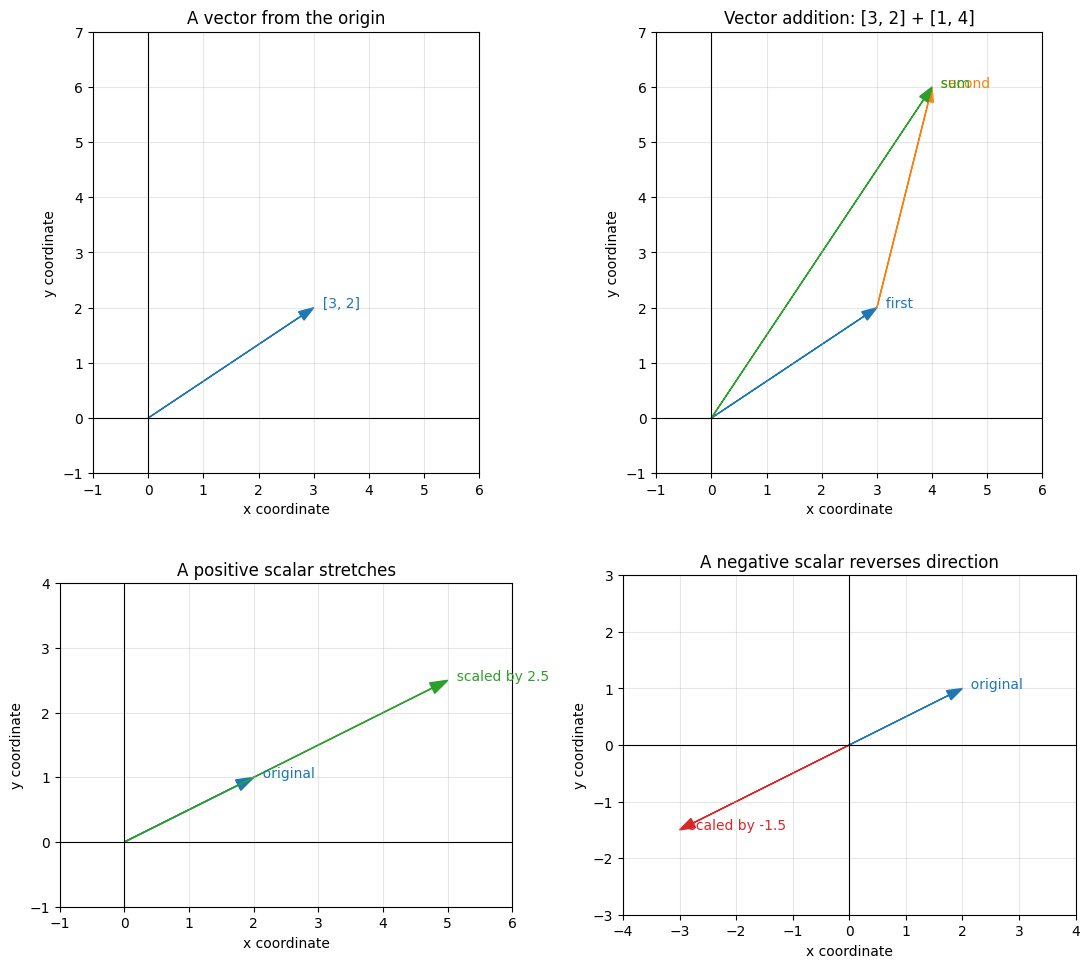

Sum vector: [4.0, 6.0]
Positive scaled vector: [5.0, 2.5]
Negative scaled vector: [-3.0, -1.5]


In [19]:
import matplotlib.pyplot as plt
from matplotlib.axes import Axes


def draw_arrow(
    axes: Axes,
    start: list[float],
    vector: list[float],
    color: str,
    label: str,
) -> None:
    axes.arrow(
        start[0],
        start[1],
        vector[0],
        vector[1],
        color=color,
        head_width=0.18,
        length_includes_head=True,
    )
    axes.text(
        start[0] + vector[0],
        start[1] + vector[1],
        f"  {label}",
        color=color,
    )


first_vector_2d = [3.0, 2.0]
second_vector_2d = [1.0, 4.0]
sum_vector_2d = add_vectors(first_vector_2d, second_vector_2d)
original_vector_2d = [2.0, 1.0]
positive_scaled_vector = multiply_vector_by_scalar(2.5, original_vector_2d)
negative_scaled_vector = multiply_vector_by_scalar(-1.5, original_vector_2d)

figure, axes_grid = plt.subplots(2, 2, figsize=(11, 10))
axes = axes_grid.flatten()

draw_arrow(axes[0], [0.0, 0.0], first_vector_2d, "tab:blue", "[3, 2]")
axes[0].set_title("A vector from the origin")

draw_arrow(axes[1], [0.0, 0.0], first_vector_2d, "tab:blue", "first")
draw_arrow(axes[1], first_vector_2d, second_vector_2d, "tab:orange", "second")
draw_arrow(axes[1], [0.0, 0.0], sum_vector_2d, "tab:green", "sum")
axes[1].set_title("Vector addition: [3, 2] + [1, 4]")

draw_arrow(axes[2], [0.0, 0.0], original_vector_2d, "tab:blue", "original")
draw_arrow(
    axes[2],
    [0.0, 0.0],
    positive_scaled_vector,
    "tab:green",
    "scaled by 2.5",
)
axes[2].set_title("A positive scalar stretches")

draw_arrow(axes[3], [0.0, 0.0], original_vector_2d, "tab:blue", "original")
draw_arrow(
    axes[3],
    [0.0, 0.0],
    negative_scaled_vector,
    "tab:red",
    "scaled by -1.5",
)
axes[3].set_title("A negative scalar reverses direction")

axis_limits = [(-1, 6, -1, 7), (-1, 6, -1, 7), (-1, 6, -1, 4), (-4, 4, -3, 3)]

for current_axes, (x_min, x_max, y_min, y_max) in zip(
    axes,
    axis_limits,
    strict=True,
):
    current_axes.axhline(0, color="black", linewidth=0.8)
    current_axes.axvline(0, color="black", linewidth=0.8)
    current_axes.set_xlim(x_min, x_max)
    current_axes.set_ylim(y_min, y_max)
    current_axes.set_aspect("equal", adjustable="box")
    current_axes.set_xlabel("x coordinate")
    current_axes.set_ylabel("y coordinate")
    current_axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Sum vector:", sum_vector_2d)
print("Positive scaled vector:", positive_scaled_vector)
print("Negative scaled vector:", negative_scaled_vector)

The addition panel places the second arrow at the endpoint of the first arrow.

The sum runs from the origin to the final endpoint.

A positive scalar preserves direction, while a negative scalar reverses direction.

## Vectors in language models

The same ordered-list structure can represent many different objects.

A **token embedding** represents a token, a **hidden state** stores intermediate information, a **parameter row** participates in a learned calculation, and an **output vector** can hold token scores.

The role of a vector comes from how the model uses it, not from the Python list itself.

In [20]:
token_embedding = [0.12, -0.44, 0.87, 0.03]
hidden_state = [0.5, -1.2, 0.0, 2.1]
parameter_row = [1.5, -0.2, 0.0, 0.8]
output_scores = [2.1, -0.5, 0.7, 1.3]

named_vectors = {
    "token embedding": token_embedding,
    "hidden state": hidden_state,
    "parameter row": parameter_row,
    "output scores": output_scores,
}

for name, example_vector in named_vectors.items():
    print(f"{name:>16}: {example_vector}  dimension={len(example_vector)}")

 token embedding: [0.12, -0.44, 0.87, 0.03]  dimension=4
    hidden state: [0.5, -1.2, 0.0, 2.1]  dimension=4
   parameter row: [1.5, -0.2, 0.0, 0.8]  dimension=4
   output scores: [2.1, -0.5, 0.7, 1.3]  dimension=4


These numbers are illustrative, not learned values from a real model.

Individual embedding coordinates usually do not have simple standalone meanings.

Their useful meaning comes from patterns across the whole vector and the calculations around it.

### A tiny fake embedding table

An embedding table can map each token to a vector of the same dimension.

In [21]:
token_to_embedding = {
    "cat": [0.2, 0.8, -0.1],
    "dog": [0.3, 0.7, -0.2],
    "mat": [-0.5, 0.1, 0.9],
}

for token, embedding in token_to_embedding.items():
    print(f"token={token!r:>5}  embedding={embedding}  dimension={len(embedding)}")

token='cat'  embedding=[0.2, 0.8, -0.1]  dimension=3
token='dog'  embedding=[0.3, 0.7, -0.2]  dimension=3
token='mat'  embedding=[-0.5, 0.1, 0.9]  dimension=3


The vectors have matching dimensions, so we can combine or compare them with vector operations.

Adding fake embeddings is mathematically valid, although this toy sum does not yet have a trained model interpretation.

In [22]:
cat_embedding = token_to_embedding["cat"]
mat_embedding = token_to_embedding["mat"]
combined_embedding = add_vectors(cat_embedding, mat_embedding)

print("cat embedding:", cat_embedding)
print("mat embedding:", mat_embedding)
print("combined vector:", combined_embedding)

cat embedding: [0.2, 0.8, -0.1]
mat embedding: [-0.5, 0.1, 0.9]
combined vector: [-0.3, 0.9, 0.8]


### A dot product can produce a score

Later, models will repeatedly take dot products between input-like vectors and parameter vectors.

The result is one score that can feed into another calculation.

In [23]:
hidden_state = [0.5, -1.0, 2.0]
parameter_row = [1.5, 0.25, -0.75]

score = print_dot_product_steps(hidden_state, parameter_row)

print("Score:", score)

Dot product calculation
----------------------------------------
position 0: 0.5 × 1.5 = 0.75
position 1: -1.0 × 0.25 = -0.25
position 2: 2.0 × -0.75 = -1.5
Products: [0.75, -0.25, -1.5]
Sum: 0.75 + -0.25 + -1.5 = -1.0
Score: -1.0


## Order changes calculations

Two vectors with the same collection of numbers can produce different scores when their coordinates are reordered.

In [24]:
first_embedding = [0.2, 0.8, -0.1]
reordered_embedding = [-0.1, 0.8, 0.2]
parameter_row = [1.5, 0.25, -0.75]

first_score = dot_product(first_embedding, parameter_row)
reordered_score = dot_product(reordered_embedding, parameter_row)

print("First embedding score:", first_score)
print("Reordered embedding score:", reordered_score)
print("Scores are equal:", first_score == reordered_score)

First embedding score: 0.575
Reordered embedding score: -0.10000000000000003
Scores are equal: False


Coordinate 0 always pairs with coordinate 0, coordinate 1 with coordinate 1, and so on.

That fixed pairing is why order matters.

## Catch common mistakes

The validation helpers give focused errors for empty vectors, nonnumeric coordinates, booleans, and dimension mismatches.

In [25]:
invalid_vectors: list[list[object]] = [
    [],
    [2.0, "not a number", 3.5],
    [1.0, True, 3.0],
]

for invalid_vector in invalid_vectors:
    try:
        assert_vector_of_numbers(invalid_vector)
    except (TypeError, ValueError) as error:
        print(f"{invalid_vector!r} -> {error}")

[] -> A vector must contain at least one number.
[2.0, 'not a number', 3.5] -> Coordinate at position 1 must be an int or float. Received 'not a number'.
[1.0, True, 3.0] -> Coordinate at position 1 must be an int or float. Received True.


In [26]:
try:
    add_vectors(
        first_vector=[1.0, 2.0, 3.0],
        second_vector=[4.0, 5.0],
    )
except ValueError as error:
    print("Addition error:", error)

try:
    dot_product(
        first_vector=[1.0, 2.0, 3.0],
        second_vector=[4.0, 5.0],
    )
except ValueError as error:
    print("Dot-product error:", error)

Addition error: Vectors must have the same dimension. Received dimensions 3 and 2.
Dot-product error: Vectors must have the same dimension. Received dimensions 3 and 2.


A 3D vector cannot be added to or dotted with a 2D vector using these ordinary operations.

Matching dimensions ensure that every coordinate has exactly one partner.

## A clean vector-operations pipeline

The next cell combines the chapter's three central operations.

In [27]:
first_vector = [2.0, -1.0, 3.5]
second_vector = [0.5, 4.0, -2.0]
scalar = 3.0

sum_vector = add_vectors(first_vector, second_vector)
scaled_vector = multiply_vector_by_scalar(scalar, first_vector)
dot_product_result = dot_product(first_vector, second_vector)

print("Vector operations summary")
print("-" * 48)
print("First vector:               ", first_vector)
print("Second vector:              ", second_vector)
print("Vector addition result:     ", sum_vector)
print("Scalar:                     ", scalar)
print("Scalar multiplication result:", scaled_vector)
print("Dot product result:         ", dot_product_result)

assert sum_vector == [2.5, 3.0, 1.5]
assert scaled_vector == [6.0, -3.0, 10.5]
assert dot_product_result == -10.0

Vector operations summary
------------------------------------------------
First vector:                [2.0, -1.0, 3.5]
Second vector:               [0.5, 4.0, -2.0]
Vector addition result:      [2.5, 3.0, 1.5]
Scalar:                      3.0
Scalar multiplication result: [6.0, -3.0, 10.5]
Dot product result:          -10.0


## What not to do

- Do not treat a vector as an unordered bag of numbers.
- Do not add vectors with different dimensions.
- Do not take a dot product of vectors with different dimensions.
- Do not confuse a vector with a token ID.
- Do not assume learned coordinates have obvious meanings in isolation.
- Do not reach for NumPy yet, because the goal here is to see the loops directly.

## Gotchas

A vector is ordered, and its dimension is the number of coordinates.

Vector addition works coordinate by coordinate and returns a vector.

Scalar multiplication affects every coordinate and returns a vector.

A dot product multiplies matching coordinates, sums the products, and returns one number.

The 2D arrow diagrams are useful intuition, but model vectors can have hundreds or thousands of dimensions.

## Takeaways

A vector is an ordered list of numbers, such as `vector = [2.0, -1.0, 3.5]`.

The three foundational operations are `add_vectors`, `multiply_vector_by_scalar`, and `dot_product`.

Vector addition and scalar multiplication return vectors.

A dot product returns one scalar.

Later, vectors will represent token embeddings, hidden states, parameter rows, model outputs, and intermediate neural-network calculations.

## What comes next

The next chapter introduces matrices as lists of lists.

A matrix can be viewed as a table of numbers or a list of vector rows.

Matrices will let us organize many vector operations at once and move closer to understanding neural-network layers.